In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
import seaborn as sns




In [ ]:
X , y = make_circles(n_samples = 100 , noise = 0.1 , random_state = 1 )

In [ ]:
X

array([[-0.63640493, -0.36870191],
       [-0.24465976, -0.73659196],
       [-0.46597138, -1.06687743],
       [-0.70999784, -0.40841948],
       [ 0.70232238, -0.51730147],
       [-0.49776571,  0.76955129],
       [-0.31914906, -0.84899624],
       [-0.57839322, -0.49081236],
       [-0.53350227,  0.58056527],
       [-0.24733259,  0.73011595],
       [ 0.41030774, -0.73075986],
       [ 0.17181003, -0.92504802],
       [ 0.65917045,  0.62120588],
       [ 0.87625577,  0.12510879],
       [ 0.81946243, -0.01347859],
       [-0.47960986, -0.7880243 ],
       [-0.90187751, -0.70895455],
       [ 0.74827659, -0.55976747],
       [-0.74875324, -0.37153443],
       [ 0.23161178,  1.01205842],
       [ 0.81387506,  0.22821311],
       [-0.92169575,  0.20310719],
       [ 0.74650434, -0.35861224],
       [ 0.01330079,  0.68169193],
       [-0.72651409,  0.58630948],
       [-0.33930852, -1.0080984 ],
       [ 0.49009938, -0.62509577],
       [-0.9539309 , -0.33410313],
       [ 0.6927241 ,

<Axes: >

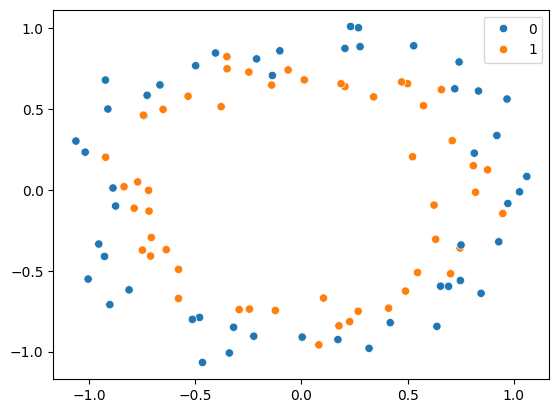

In [ ]:
sns.scatterplot(x= X[:,0], y = X[:,1] , hue = y)


In [ ]:
X_train , X_test ,y_train,y_test = train_test_split(X,y , test_size = 0.2 , random_state = 1)

In [81]:
model = Sequential()
model.add(Dense(56, input_dim = 2 , activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

In [82]:
model.compile(loss = 'binary_crossentropy' , optimizer = 'adam' , metrics = ['accuracy'])

In [83]:
history = model.fit(X_train,y_train ,  validation_data=(X_test, y_test) ,epochs = 1000  , verbose = 0)

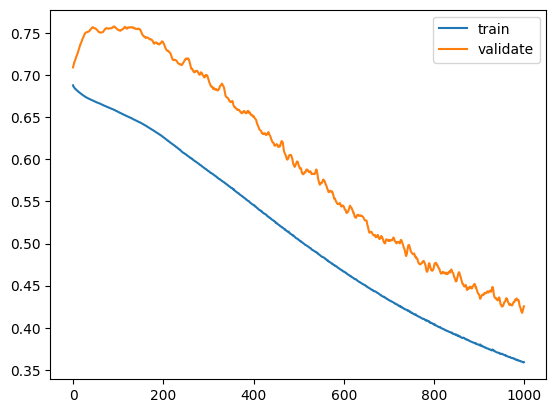

In [84]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validate'])
plt.show()

overfitting clearly happens

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


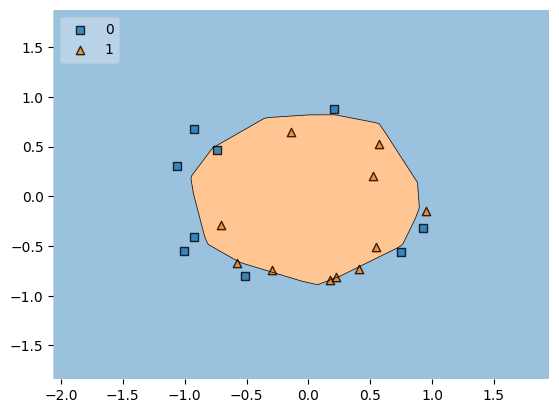

In [85]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

Early stooping concepts : we could literally see that we are facing overfitting , early stopping helps as know when overfitting starts and then stops adding more epochs

In [87]:
model = Sequential()
model.add(Dense(56 , input_dim = 2 , activation ='relu'))
model.add(Dense(1,activation='sigmoid'))

In [88]:
model.compile(loss = 'binary_crossentropy' ,optimizer ='adam' ,metrics=['accuracy'] )

In [90]:
callback = EarlyStopping(
  monitor = 'val_loss',
  min_delta = 0.001,
  patience = 50,
  verbose = 1,
  mode ='auto',
  baseline = None,
  restore_best_weights = True
)

In [91]:
history = model.fit(X_train , y_train , validation_data=(X_test, y_test), epochs = 1000 , callbacks = callback)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 0.5125 - loss: 0.6877 - val_accuracy: 0.4500 - val_loss: 0.6975
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5125 - loss: 0.6861 - val_accuracy: 0.4500 - val_loss: 0.7000
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5125 - loss: 0.6850 - val_accuracy: 0.4500 - val_loss: 0.7022
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5125 - loss: 0.6839 - val_accuracy: 0.4500 - val_loss: 0.7041
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5125 - loss: 0.6832 - val_accuracy: 0.4500 - val_loss: 0.7065
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5125 - loss: 0.6823 - val_accuracy: 0.4500 - val_loss: 0.7082
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5125 - loss: 0.6816 - val_accuracy: 0.4500 - val_loss: 0.7103
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5125 - loss: 0.6808 - val_accuracy: 0.4500 - 

we could literally see that early stopping stops the model getting further trained .

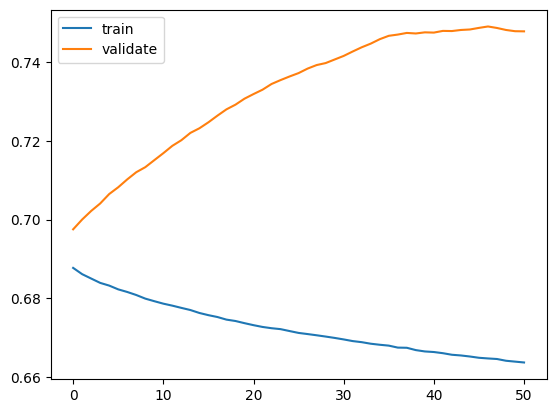

In [92]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validate'])
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


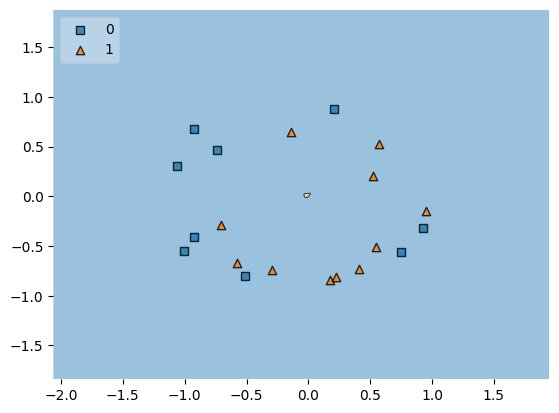

In [93]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()